# exd figure 6a 

In [18]:
# 读入数据
library(readxl)
library(dplyr)
library(ggplot2)
library(tidyr)
raw <- read_excel("PhytoBench-Knowledge-ID_250923_check_results_renamed.xlsx")


In [20]:
head(raw)

ID,species,query,answer,reference,prompts,fanhua_prompts,Pangu-NLP-N2-128K (keyword),Pangu-NLP-N2-128K (semantic),Pangu-NLP-N2-128K (hybrid),⋯,Phyto-Reasoner (keyword)_check,Phyto-Reasoner (semantic)_check,Phyto-Reasoner (hybrid)_check,DeepSeek-V3_check,DeepSeek-R1_check,Gemini-2.5-Pro_check,Grok-3-Beta_check,O3_check,GPT-5_check,Claude-4.1-Opus_check
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A_1,Arabidopsis thaliana,"Encodes a plant U-Box protein that is capable of binding and ubiquitinating a variety of targets including MYC2,LRR1,KIN and acting as an E3 ligase. Regulates a number of physiological hormonal and environment al responses via selective degradation of targets.Unlike PUB10, its closest homolog in Arabidopsis, it does not appear to play a major role in the MeJA-mediated response.",AT1G23030|PLANT U-BOX PROTEIN 11|PUB11,"Arabidopsis U-box E3 ubiquitin ligase PUB11 negatively regulates drought tolerance by degrading the receptor-like protein kinases LRR1 and KIN7|PUB11-Dependent Ubiquitination of the Phospholipid Flippase ALA10 Modifies ALA10 Localization and Affects the Pool of Linolenic Phosphatidylcholine|News from the PUB: plant U-box type E3 ubiquitin ligases.|PLANT U-BOX PROTEIN10 Regulates MYC2 Stability in Arabidopsis|Transcriptome analyses show changes in gene expression to accompany pollen germination and tube growth in Arabidopsis.|Genome-wide analysis of Arabidopsis responsive transcriptome to nitrogen limitation and its regulation by the ubiquitin ligase gene NLA.|Identification of 118 Arabidopsis transcription factor and 30 ubiquitin-ligase genes responding to chitin, a plant-defense elicitor.|Comprehensive comparison of auxin-regulated and brassinosteroid-regulated genes in Arabidopsis.|Armadillo repeat proteins: beyond the animal kingdom.|Nitric oxide-mediated transcriptional changes in Arabidopsis thaliana.","Based on the genomic and functional data and the reference materials provided below, identify the most relevant gene ID or gene names that match the {{species}}. SCIENTIFIC REQUIREMENTS: 1. Analyze the functional annotation, molecular mechanisms, and phenotypic effects described in the query. 2. Prioritize genes based on: - Functional relevance to the described biological processes - Known interaction networks and pathway participation - Regulatory roles and expression patterns consistent with the description - Evolutionary conservation of function across related species 3. Select ONLY the top 1-4 most significant genes that fulfill these criteria. IMPORTANT FORMATTING INSTRUCTIONS: 1. Your ENTIRE response must follow this EXACT format: Output: {""Gene Names"": ""GeneA | GeneB | GeneC | GeneD""} 2. Use pipe symbols (|) as separators between gene names 3. Include at most 4 gene names 4. DO NOT include brackets [] in your output 5. DO NOT include any text before or after the output format 6. Remember: The answer is usually not explicitly stated in the question. # Genomic/Functional Information: <Query> {{query}} </Query> Based on reference material availability: 1. **When references material are provided**: - Synthesize evidence from both query content and reference materials - Validate candidate genes against experimental data in references 2. **When references material are not provided**: - Rely strictly on the genomic/functional information in the query - Prioritize evolutionarily conserved functional annotations # reference materials <Reference Materials> {{搜索结果}} </Reference Materials>","Drawing from the genomic and functional datasets along with the reference resources listed below, determine the most pertinent gene ID or gene names corresponding to the Arabidopsis thaliana. SCIENTIFIC CRITERIA: 1. Evaluate the functional annotations, molecular pathways, and phenotypic impacts outlined in the query. 2. Rank genes according to: - Relevance to the specified biological functions - Established interaction networks an

In [21]:

transform_results <- function(result_data, model_columns) {
  res <- data.frame(TRUE_Count = integer(), Total_Count = integer(), TRUE_Ratio = numeric(),
                    model = character(), type = character(), stringsAsFactors = FALSE)
  for (m in model_columns) {
    mc <- paste0(m, "_check")
    if (!(mc %in% colnames(result_data))) next
    for (sp in unique(result_data$species)) {
      sub <- result_data[result_data$species == sp, ]
      tc <- sum(sub[[mc]] == "TRUE", na.rm = TRUE)
      tt <- sum(!is.na(sub[[mc]]))
      res <- rbind(res, data.frame(TRUE_Count = tc, Total_Count = tt,
                                   TRUE_Ratio = ifelse(tt > 0, tc / tt, NA),
                                   model = m, type = sp, stringsAsFactors = FALSE))
    }
  }
  res
}


In [23]:
pangu_order <- c(
  "Pangu-NLP-N2-128K (keyword)", "Pangu-NLP-N2-128K (semantic)", "Pangu-NLP-N2-128K (hybrid)",
  "Phyto-Chatbot (keyword)", "Phyto-Chatbot (semantic)", "Phyto-Chatbot (hybrid)",
  "Pangu-NLP-N2-Reasoner-128K (keyword)", "Pangu-NLP-N2-Reasoner-128K (semantic)", "Pangu-NLP-N2-Reasoner-128K (hybrid)",
  "Phyto-Reasoner (keyword)", "Phyto-Reasoner (semantic)", "Phyto-Reasoner (hybrid)"
)

raw$species <- ifelse(raw$species %in% c("Zea mays", "Arabidopsis thaliana", 
                                         "Oryza sativa", "Triticum Aestivum", 
                                         "Glycine max"), 
                      raw$species, "Mix")

res_pangu <- transform_results(raw, pangu_order)

pangu_cols <- setNames(c(
  "#9ED8E8", "#88C9DF", "#72BAD6", "#4fc0dd", "#5CA0C9", "#4891C2",
  "#4689BB", "#3F7DB1", "#3875A8", "#2E6B9E", "#266194", "#1F578A"
), pangu_order)



sp_order <- c("Oryza sativa", "Arabidopsis thaliana", "Zea mays",
              "Glycine max", "Triticum Aestivum", "Mix")


df_long_pangu <- res_pangu %>%
  mutate(type = factor(type, levels = sp_order)) %>%
  pivot_longer(cols = TRUE_Ratio, names_to = "value", values_to = "TRUE_Ratio")

p_pangu <- ggplot(df_long_pangu, aes(x = model, y = TRUE_Ratio, fill = model)) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_wrap(~type, scales = "free_x") +
  labs(x = "Model", y = "TRUE Ratio") +
  theme_minimal(base_size = 14) +
  ylim(0, 1) +
  theme(axis.text.x = element_text(angle = 75, hjust = 1),
        panel.background = element_rect(fill = "white"),
        plot.background  = element_rect(fill = "white")) +
  scale_x_discrete(limits = pangu_order) +
  scale_fill_manual(values = pangu_cols)


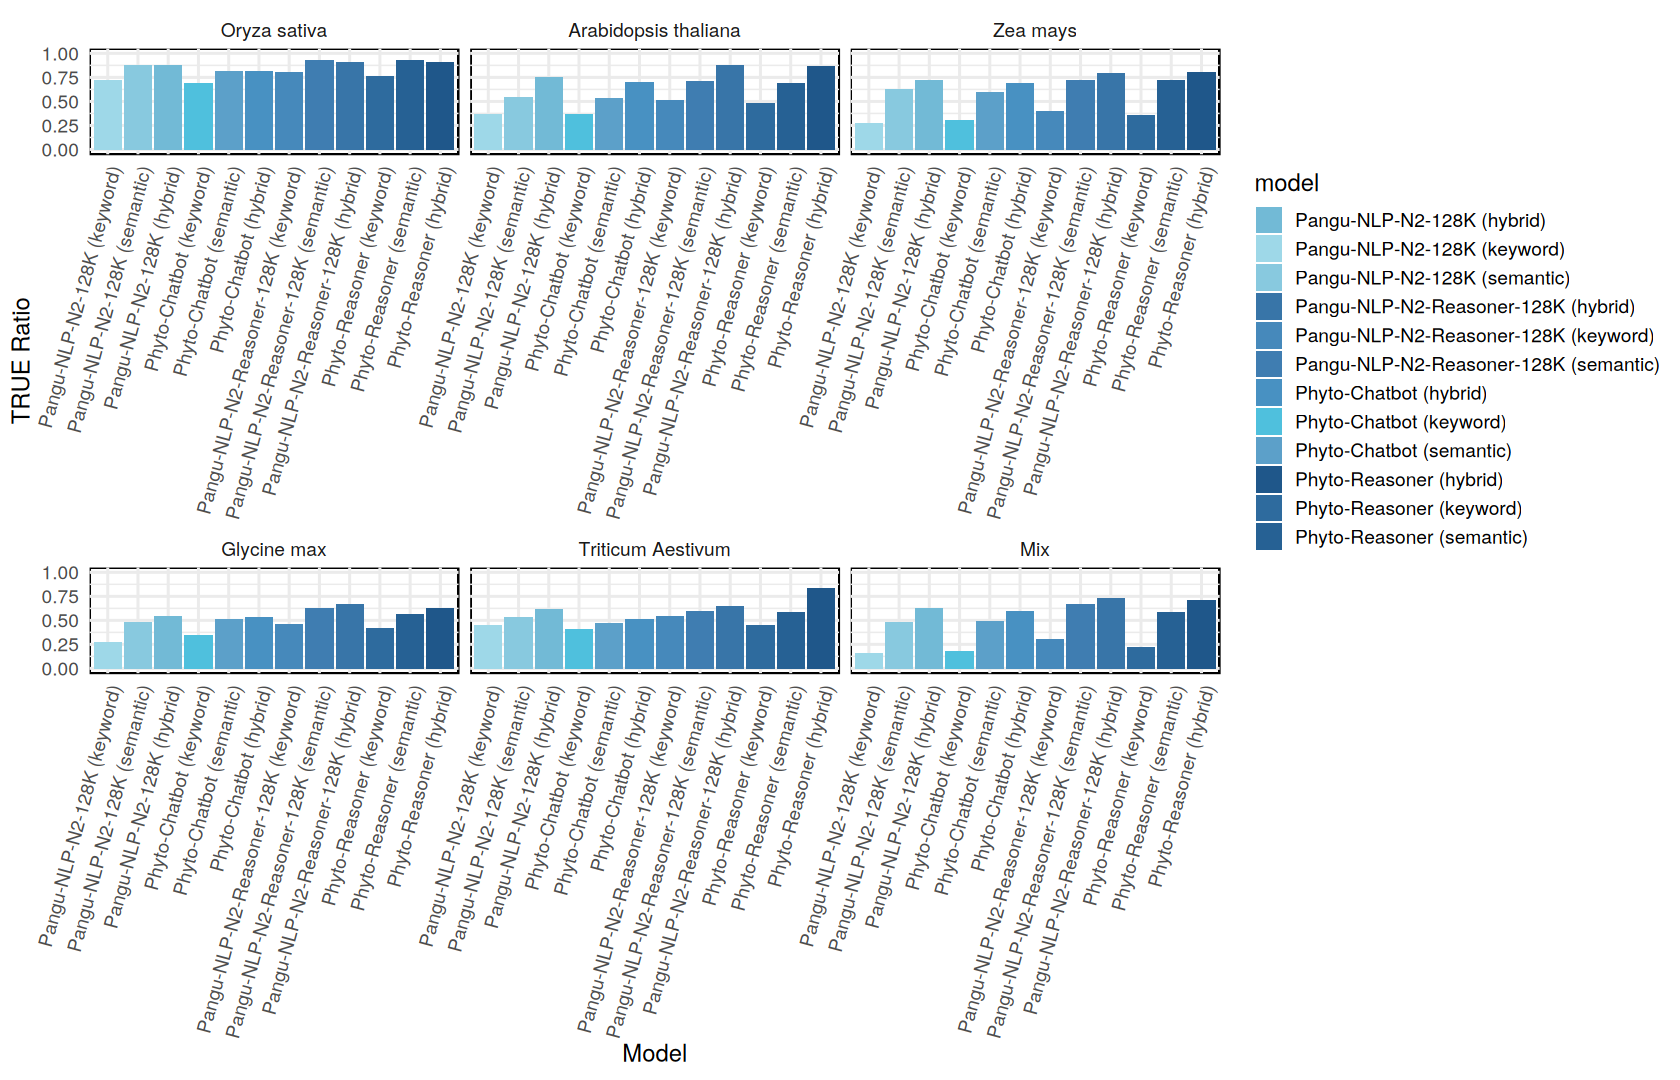

In [24]:
options(repr.plot.width = 14, repr.plot.height = 9)
p_pangu

# exd figure 6b

In [25]:

com_order_raw <- c(
  "Phyto-Chatbot (keyword)", "Phyto-Chatbot (semantic)", "Phyto-Chatbot (hybrid)",
  "Phyto-Reasoner (keyword)", "Phyto-Reasoner (semantic)", "Phyto-Reasoner (hybrid)",
  "DeepSeek-V3", "DeepSeek-R1", "Gemini-2.5-Pro", "Claude-4.1-Opus", "GPT-5", "Grok-3-Beta", "O3"
)

res_com   <- transform_results(raw, com_order_raw)


res_com_processed <- res_com %>%
  mutate(model = case_when(
    model %in% c("Phyto-Chatbot (hybrid)", "Phyto-Chatbot (keyword)", "Phyto-Chatbot (semantic)") ~ "Phyto-Chatbot",
    model %in% c("Phyto-Reasoner (hybrid)", "Phyto-Reasoner (keyword)", "Phyto-Reasoner (semantic)") ~ "Phyto-Reasoner",
    TRUE ~ model 
  )) %>%
  group_by(model, type) %>%
  summarise(
    TRUE_Count = mean(TRUE_Count),
    Total_Count = mean(Total_Count),
    TRUE_Ratio = mean(TRUE_Ratio),
    .groups = 'drop'
  ) %>%
  select(TRUE_Count, Total_Count, TRUE_Ratio, model, type)



df_long_com <- res_com_processed %>%
  mutate(type = factor(type, levels = sp_order)) %>%
  pivot_longer(cols = TRUE_Ratio, names_to = "value", values_to = "TRUE_Ratio")


com_order <- c(
  "Phyto-Reasoner",
  "Phyto-Chatbot", 
  "GPT-5",
  "O3",
  "Gemini-2.5-Pro",
  "Claude-4.1-Opus",
  "Grok-3-Beta",
  "DeepSeek-V3",
  "DeepSeek-R1"
)

com_cols <- setNames(
  c(
    rgb(17, 34, 66, maxColorValue = 255),   # Phyto-Reasoner (hybrid)
    rgb(23, 48, 93, maxColorValue = 255),   # Phyto-Chatbot (hybrid)
    rgb(30, 69, 129, maxColorValue = 255),  # GPT-5
    rgb(43, 95, 150, maxColorValue = 255),  # O3
    rgb(66, 121, 170, maxColorValue = 255), # Gemini-2.5-Pro
    rgb(98, 150, 192, maxColorValue = 255), # Claude-4.1-Opus
    rgb(131, 173, 208, maxColorValue = 255), # Grok-3-Beta
    rgb(164, 199, 226, maxColorValue = 255), # DeepSeek-V3
    rgb(191, 219, 237, maxColorValue = 255)  # DeepSeek-R1
  ),
  com_order
)


p_com <- ggplot(df_long_com, aes(x = model, y = TRUE_Ratio, fill = model)) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_wrap(~type, scales = "free_x") +
  labs(x = "Model", y = "TRUE Ratio") +
  theme_minimal(base_size = 14) +
  ylim(0, 1) +
  theme(
    axis.text.x = element_text(angle = 75, hjust = 1),
    panel.background = element_rect(fill = "white"),
    plot.background = element_rect(fill = "white"),
    strip.background = element_rect(fill = "white")  
  ) +
  scale_x_discrete(limits = com_order) +
  scale_fill_manual(values = com_cols)



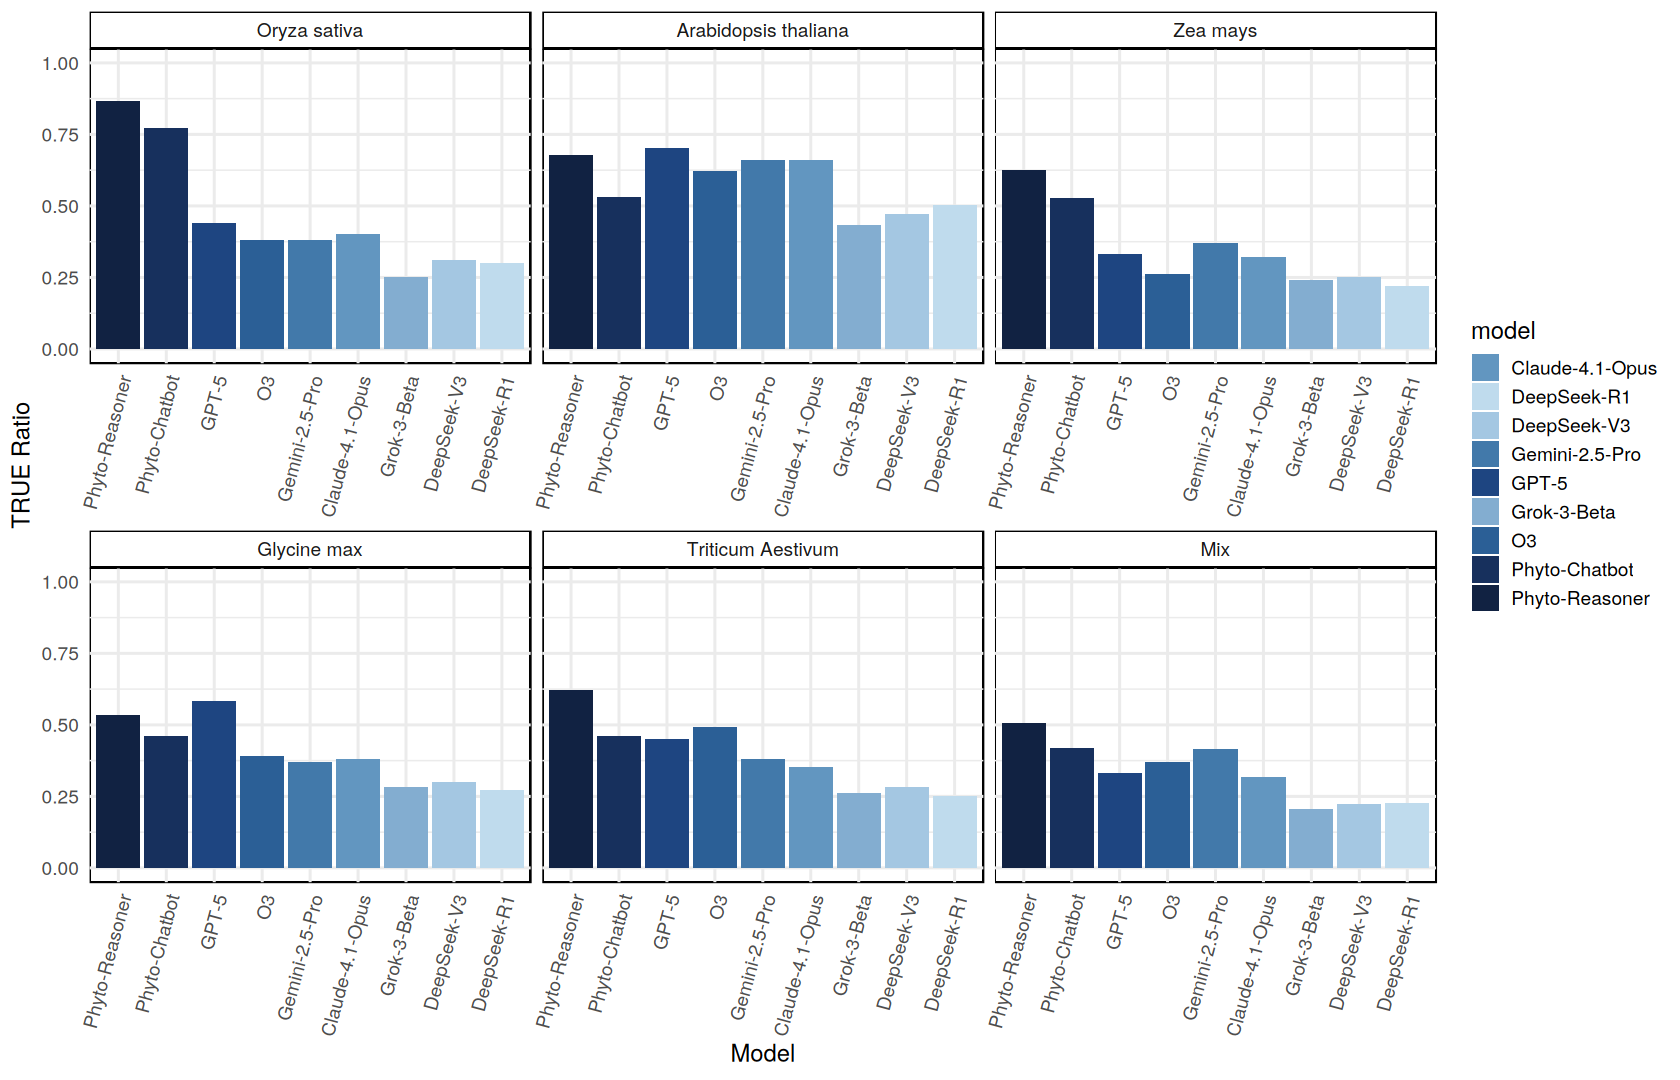

In [26]:
options(repr.plot.width = 14, repr.plot.height = 9)
p_com

# exd figure 6c

In [ ]:

library(tidyverse)
library(fmsb)      
library(ggradar)    
library(ComplexHeatmap)
library(circlize)  

data <- read.csv("aggregated_results.csv")

library(dplyr)
rename_map <- c(
  # 盘古-chat
  "chat_L0_ragkeyword" = "Pangu-NLP-N2-128K (keyword)",
  "chat_L0_ragrank"    = "Pangu-NLP-N2-128K (semantic)",
  "chat_L0_ragsearch"  = "Pangu-NLP-N2-128K (hybrid)",
  "chat_L1_ragkeyword" = "Phyto-Chatbot (keyword)",
  "chat_L1_ragrank"    = "Phyto-Chatbot (semantic)",
  "chat_L1_ragsearch"  = "Phyto-Chatbot (hybrid)",
  # 盘古-reasoner
  "R_L0_ragkeyword" = "Pangu-NLP-N2-Reasoner-128K (keyword)",
  "R_L0_ragrank"    = "Pangu-NLP-N2-Reasoner-128K (semantic)",
  "R_L0_ragsearch"  = "Pangu-NLP-N2-Reasoner-128K (hybrid)",
  "R_L1_ragkeyword" = "Phyto-Reasoner (keyword)",
  "R_L1_ragrank"    = "Phyto-Reasoner (semantic)",
  "R_L1_ragsearch"  = "Phyto-Reasoner (hybrid)",
  ## 普通模型
  "deepseek_v3"              = "DeepSeek-V3",
  "deepseek_r1"              = "DeepSeek-R1",
  "grok_3_beta"              = "Grok-3-Beta",
  "claude_opus_4_1"          = "Claude-4.1-Opus",
  "gpt_5"                    = "GPT-5",
  "o3"                       = "O3",
  "gemini_2_5_preview"       = "Gemini-2.5-Pro")

data_selected <- data %>% 
  select(
    X,
    bleu.bleu.1, bleu.bleu.2, bleu.bleu.3, bleu.bleu.4,
    rouge.rouge.1.f,
    rouge.rouge.2.f,
    rouge.rouge.l.f,
    bert_score.precision,
    bert_score.f1,
    bert_score.recall
  ) %>% 
  # 1. 先重命名 X 列里的模型
  mutate(X = recode(X, !!!rename_map)) %>% 
  # 2. 再重命名指标列
  rename(
    `BLEU-1`               = bleu.bleu.1,
    `BLEU-2`               = bleu.bleu.2,
    `BLEU-3`               = bleu.bleu.3,
    `BLEU-4`               = bleu.bleu.4,
    `ROUGE-1 F1`           = rouge.rouge.1.f,
    `ROUGE-2 F1`           = rouge.rouge.2.f,
    `ROUGE-L F1`           = rouge.rouge.l.f,
    `BERTScore Precision`  = bert_score.precision,
    `BERTScore F1`         = bert_score.f1,
    `BERTScore Recall`     = bert_score.recall
  )



data_selected <- data_selected %>% 
  mutate(X = recode(X, !!!rename_map))




## ---------- 0. 数据 ----------
# 你的 data_selected 已经就绪
ds <- data_selected %>% column_to_rownames("X")


library(dplyr)

ds %>%
  summarise(across(matches("BLEU|ROUGE|BERT"),  # 正则抓列
                   list(Min = ~min(.x, na.rm = TRUE),
                        Max = ~max(.x, na.rm = TRUE)),
                   .names = "{.col}_{.fn}"))


## ---------- 1. 雷达图 ----------
# 把 10 个指标缩放到 0-1 区间（雷达图必须）
ds_scaled <- ds %>% mutate(across(everything(), scales::rescale))

library(ggradar)


# 转换数据格式
ds_scaled_df <- data.frame(
  group = rownames(ds_scaled),
  ds_scaled,
  row.names = NULL
)

# 优化后的代码

# 绘图
# 定义模型顺序和颜色映射
model_order <- c(
  "Phyto-Reasoner (hybrid)",
  "Phyto-Reasoner (semantic)", 
  "Phyto-Reasoner (keyword)",
  "Phyto-Chatbot (hybrid)",
  "Phyto-Chatbot (semantic)",
  "Phyto-Chatbot (keyword)",
  "Pangu-NLP-N2-Reasoner-128K (hybrid)",
  "Pangu-NLP-N2-Reasoner-128K (semantic)",
  "Pangu-NLP-N2-Reasoner-128K (keyword)",
  "Pangu-NLP-N2-128K (hybrid)",
  "Pangu-NLP-N2-128K (semantic)",
  "Pangu-NLP-N2-128K (keyword)",
  "GPT-5",
  "O3",
  "Gemini-2.5-Pro",
  "Claude-4.1-Opus",
  "Grok-3-Beta",
  "DeepSeek-V3",
  "DeepSeek-R1"
)

# 创建颜色向量
colors <- setNames(
  c(
    rgb(33, 39, 58, maxColorValue = 255),    # Phyto-Reasoner (hybrid)
    rgb(40, 52, 72, maxColorValue = 255),    # Phyto-Reasoner (semantic)
    rgb(46, 65, 86, maxColorValue = 255),    # Phyto-Reasoner (keyword)
    rgb(53, 78, 96, maxColorValue = 255),    # Phyto-Chatbot (hybrid)
    rgb(60, 90, 105, maxColorValue = 255),   # Phyto-Chatbot (semantic)
    rgb(66, 103, 114, maxColorValue = 255),  # Phyto-Chatbot (keyword)
    rgb(72, 116, 122, maxColorValue = 255),  # Pangu-NLP-N2-Reasoner-128K (hybrid)
    rgb(82, 128, 128, maxColorValue = 255),  # Pangu-NLP-N2-Reasoner-128K (semantic)
    rgb(93, 139, 135, maxColorValue = 255),  # Pangu-NLP-N2-Reasoner-128K (keyword)
    rgb(106, 151, 144, maxColorValue = 255), # Pangu-NLP-N2-128K (hybrid)
    rgb(118, 163, 152, maxColorValue = 255), # Pangu-NLP-N2-128K (semantic)
    rgb(129, 174, 158, maxColorValue = 255), # Pangu-NLP-N2-128K (keyword)
    rgb(140, 184, 165, maxColorValue = 255), # GPT-5
    rgb(156, 196, 174, maxColorValue = 255), # O3
    rgb(172, 208, 184, maxColorValue = 255), # Gemini-2.5-Pro
    rgb(186, 218, 195, maxColorValue = 255), # Claude-4.1-Opus
    rgb(201, 227, 206, maxColorValue = 255), # Grok-3-Beta
    rgb(210, 228, 208, maxColorValue = 255), # DeepSeek-V3
    rgb(219, 230, 210, maxColorValue = 255)  # DeepSeek-R1
  ),
  model_order
)

# 确保数据中的模型顺序正确
ds_scaled_df$group <- factor(ds_scaled_df$group, levels = model_order)



# 检查模型数量是否匹配
n_models <- length(model_order)
print(paste("模型数量:", n_models))
print(paste("颜色数量:", length(colors)))

# 绘图代码
p <- ggradar(
  ds_scaled_df,
  group.line.width = 0.8,
  group.point.size = 1.5,
  grid.line.width = 0.4,
  grid.min = 0,
  grid.mid = 0.5,
  grid.max = 1,
  legend.position = "right",
  # 新增参数：设置网格背景色为白色
  background.circle.colour = "white",
  gridline.min.colour = "gray80",  # 最小网格线颜色调浅
  gridline.mid.colour = "gray80",  # 中间网格线颜色调浅
  gridline.max.colour = "gray80",  # 最大网格线颜色调浅
  # 设置轴标签大小
  axis.label.size = 4,  # 缩小指标标签字体大小
  legend.text.size = 10  # 控制图例文字大小
) +
  scale_fill_manual(values = colors) +
  scale_color_manual(values = colors) +
  # 修改刻度标签为0, 0.5, 1
  scale_y_continuous(
    breaks = c(0, 0.5, 1),
    labels = c("0", "0.5", "1")
  ) +
  theme(
    # 背景全白
    panel.background = element_rect(fill = "white", colour = NA),
    plot.background = element_rect(fill = "white", colour = NA),
    panel.border = element_blank(),
    axis.line = element_blank(),
    
    # 进一步缩小雷达图指标标签
    axis.text.x = element_text(size = 8, colour = "black"),  # 专门调整径向标签
    
    # 优化图例：更紧凑
    legend.position = "right",
    legend.text = element_text(size = 8),                    # 图例文字大小
    legend.title = element_blank(),
    legend.key.size = unit(0.3, "cm"),                      # 色块大小
    legend.key.height = unit(0.3, "cm"),                    # 色块高度
    legend.key.width = unit(0.3, "cm"),                     # 色块宽度
    legend.margin = margin(-5, 0, -5, 0),                   # 负边距减小间距
    legend.box.margin = margin(0, 0, 0, 0),
    legend.spacing.y = unit(0.05, "cm"),                    # 垂直间距
    legend.direction = "vertical"
  )




BLEU-1_Min,BLEU-1_Max,BLEU-2_Min,BLEU-2_Max,BLEU-3_Min,BLEU-3_Max,BLEU-4_Min,BLEU-4_Max,ROUGE-1 F1_Min,ROUGE-1 F1_Max,ROUGE-2 F1_Min,ROUGE-2 F1_Max,ROUGE-L F1_Min,ROUGE-L F1_Max,BERTScore Precision_Min,BERTScore Precision_Max,BERTScore F1_Min,BERTScore F1_Max,BERTScore Recall_Min,BERTScore Recall_Max
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.07755058,0.2648858,0.03646976,0.1720593,0.01701432,0.1233244,0.008644131,0.09010894,0.1148472,0.3265624,0.01797733,0.132743,0.1051508,0.2944282,0.4730968,0.6500484,0.5352099,0.6535978,0.5870792,0.6855051


[1] "模型数量: 19"
[1] "颜色数量: 19"


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


Ignoring unknown labels:
• size : "10"
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


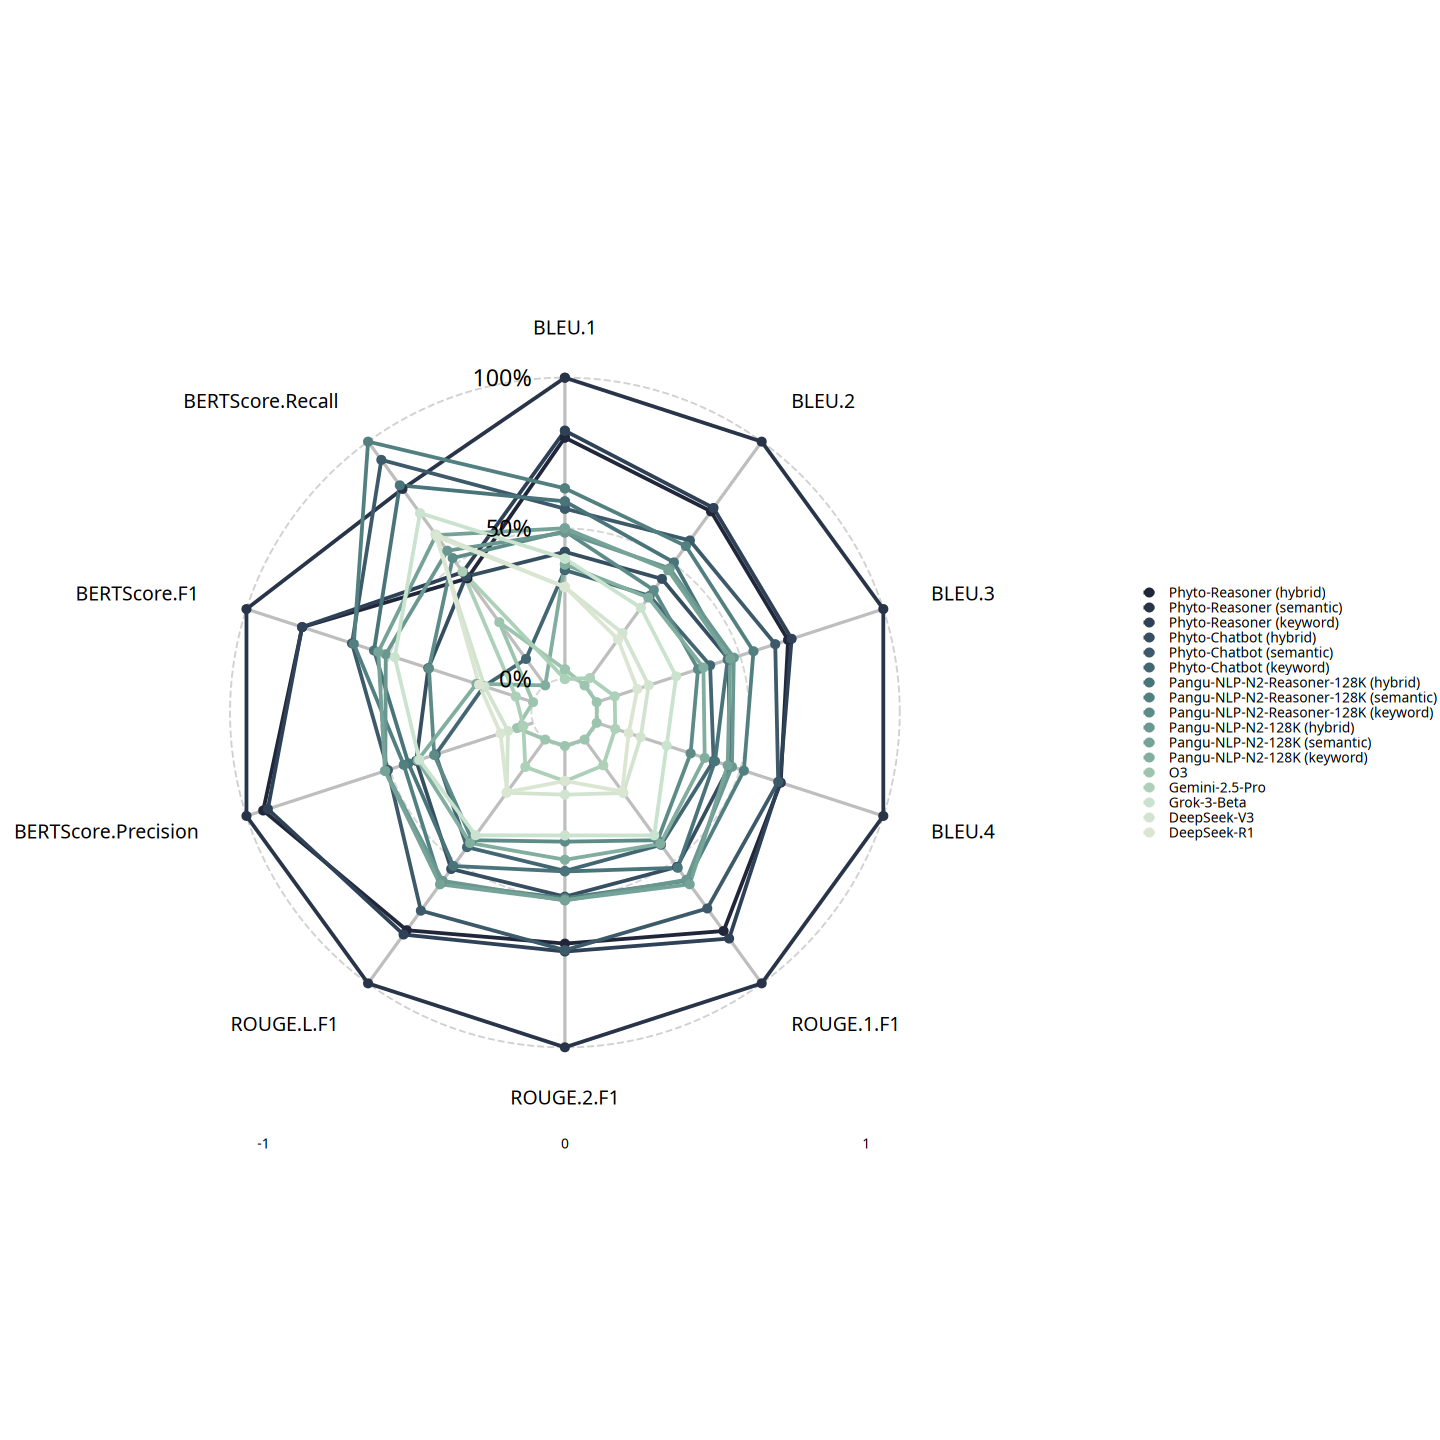

In [35]:
options(repr.plot.width = 12, repr.plot.height = 12)

print(p)

